In [1]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model

# 1. Download the pre-built MobileNet brain (without its old memory)
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze the brain so we don't accidentally break what Google already trained
base_model.trainable = False

# 2. Add our new "EcoScan" layer for 8 trash categories
x = base_model.output
x = GlobalAveragePooling2D()(x)
predictions = Dense(8, activation='softmax')(x) # 8 means 8 types of trash

# 3. Combine them into our final model
model = Model(inputs=base_model.input, outputs=predictions)

# 4. Get it ready to learn
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

print("MobileNet is ready to learn about trash!")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
MobileNet is ready to learn about trash!


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
#imported dataset from drive
# Unzip the 'archive.zip' file straight from your Google Drive
!unzip -q "/content/drive/MyDrive/archive.zip" -d waste_data/

print("Unzipped and ready for the AI!")

Unzipped and ready for the AI!


Accuracy Improvements 4 STAGES

STAGE 1

In [4]:
import tensorflow as tf
import os
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model

# 1. Build a BRAND NEW Brain (This clears out any old errors in Colab's memory)
print("Building a fresh AI brain...")
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False # Freeze the brain so we don't break Google's hard work

x = base_model.output
x = GlobalAveragePooling2D()(x)
predictions = Dense(8, activation='softmax')(x) # 8 types of trash

model = Model(inputs=base_model.input, outputs=predictions)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# 2. Automatically find the correct image folder
data_dir = 'waste_data'
for root, dirs, files in os.walk('waste_data'):
    if len(dirs) == 8:
        data_dir = root
        break

# 3. Load the images with the correct formatting
print("Loading images...")
train_data = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    label_mode='categorical',
    image_size=(224, 224),
    batch_size=32
)

# 4. The Main Event: Training
print("AI is studying the trash... grab a snack, this might take a few minutes!")
model.fit(train_data, epochs=5)

print("Done! The AI has learned how to sort the trash.")

Building a fresh AI brain...
Loading images...
Found 64000 files belonging to 8 classes.
AI is studying the trash... grab a snack, this might take a few minutes!
Epoch 1/5
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 83s 32ms/step - accuracy: 0.5443 - loss: 1.2899
Epoch 2/5
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 62s 31ms/step - accuracy: 0.6129 - loss: 1.1064
Epoch 3/5
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 62s 31ms/step - accuracy: 0.6314 - loss: 1.0559
Epoch 4/5
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 61s 31ms/step - accuracy: 0.6423 - loss: 1.0265
Epoch 5/5
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 62s 31ms/step - accuracy: 0.6490 - loss: 1.0071
Done! The AI has learned how to sort the trash.


STAGE 2

In [5]:
print("Sending the AI back to studying...")

# Let's train it for 10 MORE rounds.
# Since it already did 5, this will bring its total experience up to 15 rounds!
history = model.fit(train_data, epochs=10)

print("Extra training complete! It should be way smarter now.")

Sending the AI back to studying...
Epoch 1/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 62s 31ms/step - accuracy: 0.6535 - loss: 0.9937
Epoch 2/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 61s 31ms/step - accuracy: 0.6566 - loss: 0.9845
Epoch 3/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 62s 31ms/step - accuracy: 0.6597 - loss: 0.9761
Epoch 4/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 62s 31ms/step - accuracy: 0.6615 - loss: 0.9712
Epoch 5/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 61s 30ms/step - accuracy: 0.6641 - loss: 0.9670
Epoch 6/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 61s 31ms/step - accuracy: 0.6662 - loss: 0.9646
Epoch 7/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 62s 31ms/step - accuracy: 0.6658 - loss: 0.9618
Epoch 8/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 61s 30ms/step - accuracy: 0.6670 - loss: 0.9570
Epoch 9/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 61s 30ms/step - accuracy: 0.6663 - loss: 0.9551
Epoch 10/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 62s 31ms/step - accuracy: 0.6678 - loss: 0.9537
Extra training complete! It should be way smarter now.


STAGE 3

In [6]:
print("Unfreezing the brain for Deep Learning (Fine-Tuning)...")

# 1. Unfreeze the base model
base_model.trainable = True

# 2. Keep the bottom 100 layers frozen (basic shapes), but unfreeze the top layers (complex textures)
for layer in base_model.layers[:100]:
    layer.trainable = False

# 3. Re-compile the model with a VERY tiny learning rate so we don't break it
model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# 4. Train it for 5 final, deep-focus rounds
print("Starting final deep-focus rounds...")
history_fine = model.fit(train_data, epochs=5)

print("Fine-tuning complete! Check that new accuracy.")

Unfreezing the brain for Deep Learning (Fine-Tuning)...
Starting final deep-focus rounds...
Epoch 1/5
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 117s 47ms/step - accuracy: 0.4780 - loss: 1.9664
Epoch 2/5
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 94s 47ms/step - accuracy: 0.6200 - loss: 1.1143
Epoch 3/5
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 94s 47ms/step - accuracy: 0.6894 - loss: 0.8909
Epoch 4/5
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 93s 47ms/step - accuracy: 0.7420 - loss: 0.7401
Epoch 5/5
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 93s 46ms/step - accuracy: 0.7848 - loss: 0.6212
Fine-tuning complete! Check that new accuracy.


STAGE 4

In [7]:
import tensorflow as tf

print("Setting up Data Augmentation (The 'Different Angles' Trick)...")

# 1. Create the rules for flipping, rotating, and zooming
data_augmentation = tf.keras.Sequential([
  tf.keras.layers.RandomFlip("horizontal_and_vertical"),
  tf.keras.layers.RandomRotation(0.2), # Rotate up to 20%
  tf.keras.layers.RandomZoom(0.2),     # Zoom in/out up to 20%
])

# 2. Apply it to your existing training data
# This automatically scrambles the pictures every time the AI looks at them
augmented_train_data = train_data.map(
  lambda x, y: (data_augmentation(x, training=True), y)
)

# 3. Train it for 10 more deep-focus rounds with the tricky images!
print("Starting the overnight training... get some sleep!")
history_augmented = model.fit(augmented_train_data, epochs=10)

print("Overnight training complete! Don't forget to run the Converter block.")

Setting up Data Augmentation (The 'Different Angles' Trick)...
Starting the overnight training... get some sleep!
Epoch 1/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 844s 422ms/step - accuracy: 0.5616 - loss: 1.2628
Epoch 2/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 846s 423ms/step - accuracy: 0.6101 - loss: 1.1073
Epoch 3/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 868s 426ms/step - accuracy: 0.6329 - loss: 1.0361
Epoch 4/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 842s 421ms/step - accuracy: 0.6540 - loss: 0.9760
Epoch 5/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 837s 418ms/step - accuracy: 0.6709 - loss: 0.9322
Epoch 6/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 821s 410ms/step - accuracy: 0.6830 - loss: 0.8959
Epoch 7/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 831s 415ms/step - accuracy: 0.6978 - loss: 0.8614
Epoch 8/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 837s 418ms/step - accuracy: 0.7079 - loss: 0.8333
Epoch 9/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 833s 416ms/step - accuracy: 0.7183 - loss: 0.8061
Epoch 10/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 875s 423ms/step

TESTING MODEL'S ACCURACY

Picking a random image to test...
Found 64000 files belonging to 8 classes.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


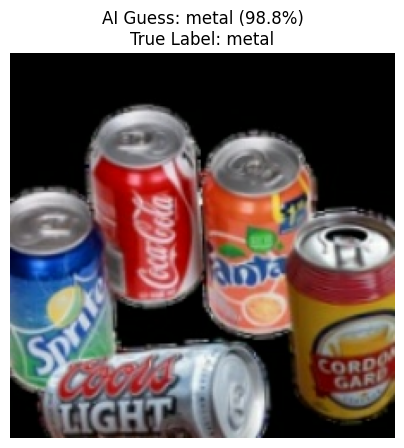

In [19]:
import tensorflow as tf
import numpy as np
import os
import matplotlib.pyplot as plt

# 1. Automatically find the folder containing the 8 trash categories
data_dir = 'waste_data'
for root, dirs, files in os.walk('waste_data'):
    if len(dirs) == 8:
        data_dir = root
        break

# Get the names of your 8 trash categories
class_names = sorted(os.listdir(data_dir))

# 2. Grab 1 random image from your dataset to test
print("Picking a random image to test...")
test_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    image_size=(224, 224),
    batch_size=1, # Just take one image
    shuffle=True
)

# Pull the image and its true label
for images, labels in test_ds.take(1):
    test_image = images[0].numpy().astype("uint8")
    true_label_idx = labels[0].numpy()
    true_class = class_names[true_label_idx]

# 3. Make the AI guess!
# Reshape image to add batch dimension (1, 224, 224, 3) for the model
img_batch = np.expand_index = np.expand_dims(test_image, axis=0)
predictions = model.predict(img_batch)
predicted_label_idx = np.argmax(predictions[0])
predicted_class = class_names[predicted_label_idx]
confidence = predictions[0][predicted_label_idx] * 100

# 4. Show the result visually
plt.figure(figsize=(5, 5))
plt.imshow(test_image)
plt.title(f"AI Guess: {predicted_class} ({confidence:.1f}%)\nTrue Label: {true_class}")
plt.axis('off')
plt.show()

CREATE .TFLITE FILE

In [20]:
# Convert the AI into a tiny mobile-friendly file
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# Save the file to your Colab folder
with open('ecoscan_mobilenet.tflite', 'wb') as f:
  f.write(tflite_model)

print("Saved! Your .tflite file is ready for the mobile app.")

Saved artifact at '/tmp/tmpq99jl5x9'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_156')
Output Type:
  TensorSpec(shape=(None, 8), dtype=tf.float32, name=None)
Captures:
  139442560863120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139442560864656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139442560864464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139442560863888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139442560865232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139442560862160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139442560864848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139442560865040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139442560864080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139442560866192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1394425608